# Autoencoder for Image Denoising on MNIST

In this notebook we will build a Convolutional Autoencoder to remove noise from MNIST images.

The idea is simple:
- We take clean MNIST images
- Add Gaussian noise to them
- Train the autoencoder to take noisy images as input and output clean images

The model learns to ignore the noise and reconstruct the original digit.

## 1. Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

print('All libraries imported successfully')

All libraries imported successfully


## 2. Device Setup

We will use GPU if available, otherwise CPU.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 3. Loading the MNIST Dataset

MNIST has 60,000 training images and 10,000 test images. Each image is 28x28 grayscale.

In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

print(f'Training samples : {len(train_data)}')
print(f'Testing samples  : {len(test_data)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 66.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]

Training samples : 60000
Testing samples  : 10000


## 4. Visualizing Some Clean MNIST Images

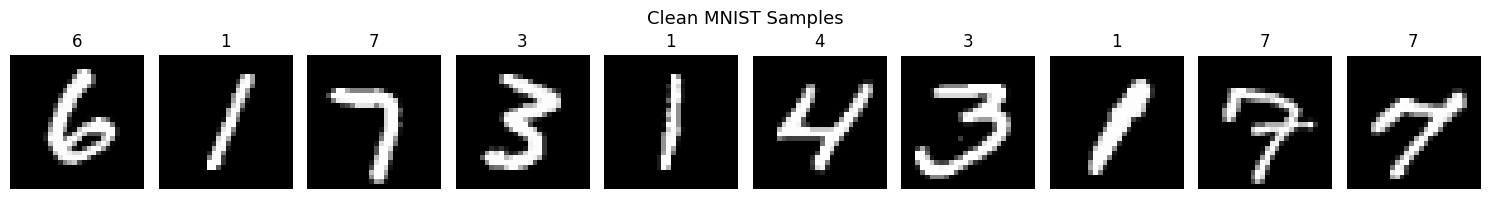

In [4]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')

plt.suptitle('Clean MNIST Samples', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Adding Noise to the Images

We add Gaussian noise to the images. The `noise_factor` controls how much noise is added.
We also clamp the pixel values between 0 and 1 to keep them valid.

In [5]:
def add_noise(images, noise_factor=0.4):
    noisy_images = images + noise_factor * torch.randn_like(images)
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

### Visualizing Clean vs Noisy Images

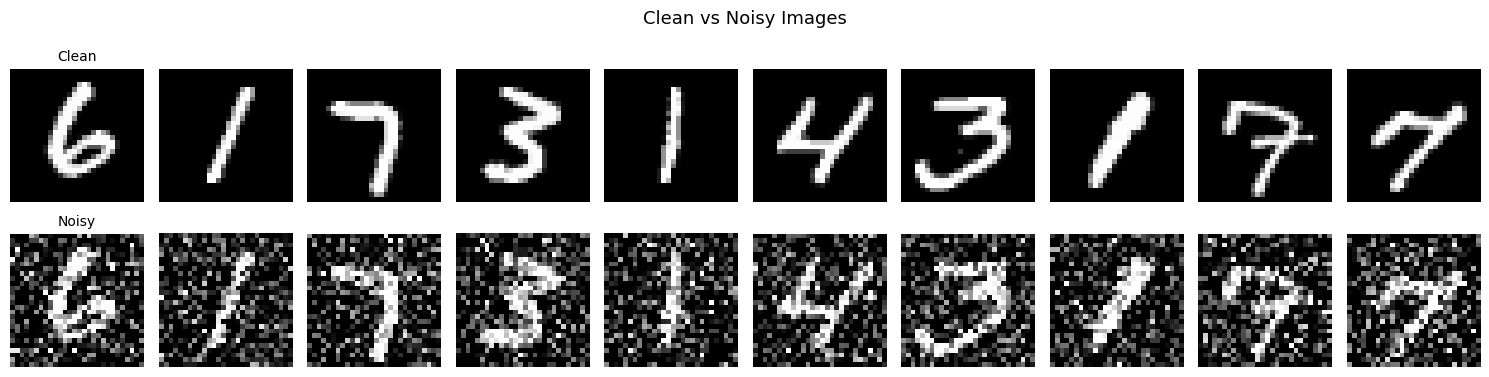

In [6]:
noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    # top row - clean
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # bottom row - noisy
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title('Clean', fontsize=10)
axes[1, 0].set_title('Noisy', fontsize=10)

plt.suptitle('Clean vs Noisy Images', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Building the Autoencoder

Our autoencoder has two parts:
- **Encoder** : Compresses the image using Conv + MaxPool layers
- **Decoder** : Reconstructs the image using ConvTranspose layers

Input: 28x28 noisy image → Encoder → compressed representation → Decoder → 28x28 clean image

In [7]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (1,28,28) -> (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (32,28,28) -> (32,14,14)

            nn.Conv2d(32, 16, kernel_size=3, padding=1),  # (32,14,14) -> (16,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                             # (16,14,14) -> (16,7,7)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 32, kernel_size=2, stride=2),  # (16,7,7) -> (32,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),   # (32,14,14) -> (1,28,28)
            nn.Sigmoid()   # output between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


## 7. Setting up Loss and Optimizer

We use MSELoss because we are comparing pixel values (regression task, not classification).
Adam optimizer with learning rate 0.001.

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Loss function :', criterion)
print('Optimizer     :', optimizer)

Loss function : MSELoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 8. Training the Autoencoder

For each batch:
1. Take clean images
2. Add noise to get noisy images
3. Pass noisy images through the model
4. Calculate loss between model output and **clean** images
5. Backpropagate and update weights

In [9]:
epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images).to(device)

        # forward pass
        outputs = model(noisy_images)
        loss = criterion(outputs, images)   # compare output with clean images

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}')

Epoch [1/10]  Loss: 0.0326
Epoch [2/10]  Loss: 0.0136
Epoch [3/10]  Loss: 0.0127
Epoch [4/10]  Loss: 0.0122
Epoch [5/10]  Loss: 0.0119
Epoch [6/10]  Loss: 0.0117
Epoch [7/10]  Loss: 0.0116
Epoch [8/10]  Loss: 0.0114
Epoch [9/10]  Loss: 0.0113
Epoch [10/10]  Loss: 0.0113


## 9. Plotting the Training Loss

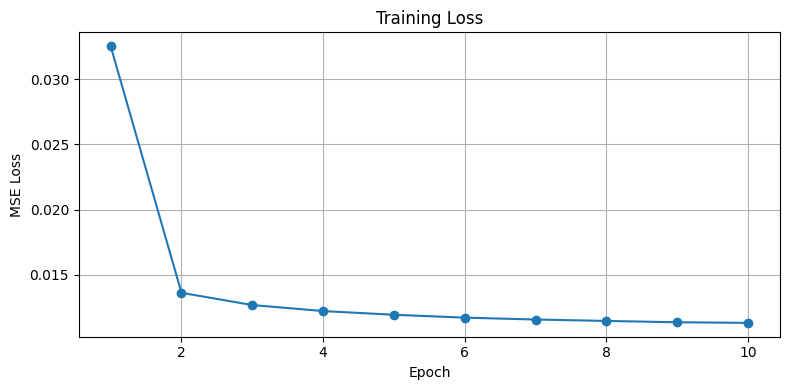

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Testing the Model - Denoising Results

Now let's see how well our model removes noise.
We will show 3 rows:
- **Row 1** : Original clean images
- **Row 2** : Noisy images (model input)
- **Row 3** : Denoised output (model output)

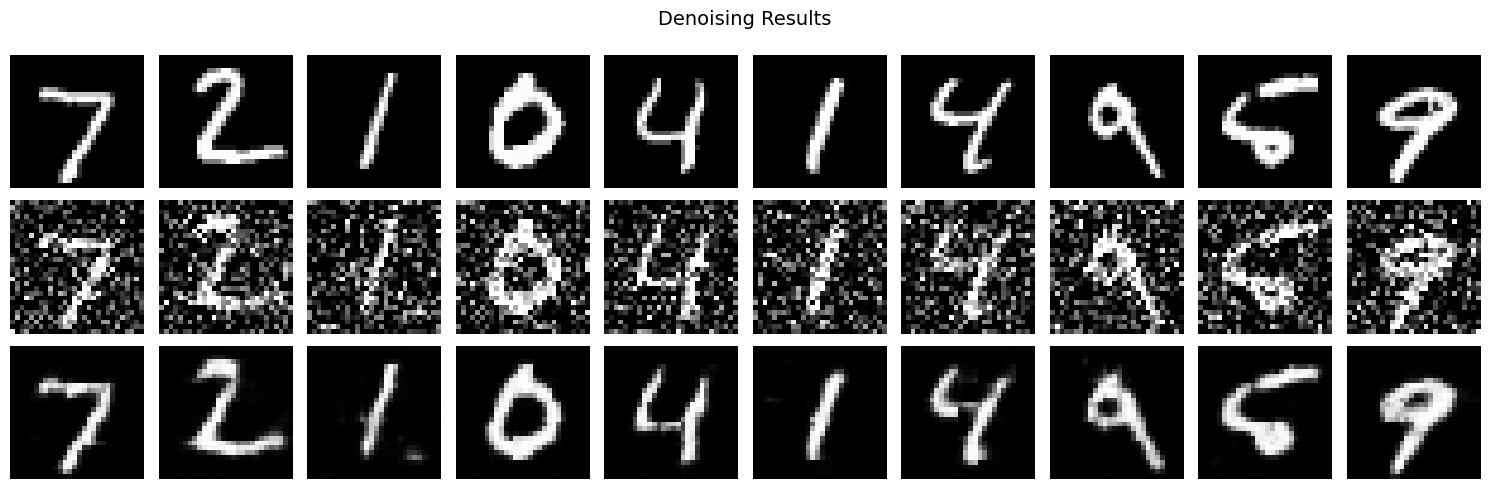

In [11]:
model.eval()

test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
noisy_test  = add_noise(test_images).to(device)

with torch.no_grad():
    denoised = model(noisy_test)

# bring tensors back to cpu for plotting
test_images = test_images.cpu()
noisy_test  = noisy_test.cpu()
denoised    = denoised.cpu()

n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))

for i in range(n):
    # original
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # noisy
    axes[1, i].imshow(noisy_test[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # denoised
    axes[2, i].imshow(denoised[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Noisy',    fontsize=10)
axes[2, 0].set_ylabel('Denoised', fontsize=10)

plt.suptitle('Denoising Results', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Saving the Model

In [12]:
torch.save(model.state_dict(), 'denoising_autoencoder.pth')
print('Model saved as denoising_autoencoder.pth')

Model saved as denoising_autoencoder.pth


## Summary

- Built a **Convolutional Autoencoder** with Encoder and Decoder blocks
- Added **Gaussian noise** to MNIST images to simulate corrupted data
- Trained the model to take noisy images as input and output clean images
- Used **MSELoss** because it is a pixel-level reconstruction (regression) task
- The model successfully learned to denoise the images as seen in the final results